In [1]:
import numpy               as np
import seaborn             as sns
import pandas              as pd
import libraries.model     as slm
import libraries.plotting  as slp
import libraries.utilities as sul
import os

# Assuming the `bin` directory is in the user's home directory
# For sqs
home_directory = os.path.expanduser("~")
bin_directory = os.path.join(home_directory, "bin")
os.environ["PATH"] += os.pathsep + bin_directory

from pymatgen.core.surface   import generate_all_slabs
from pymatgen.core.structure import Structure
from pymatgen.io.ase         import AseAtomsAdaptor
from ase.io.vasp             import write_vasp

sns.set_theme()

/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [2]:
# Define name of folder and path to reference POSCAR
general_folder = 'input/CeO2'
path_to_POSCAR = 'POSCAR-uc-CeO2'

# Whether to relax with ML-IAP the bulk structure or use the POSCAR as is
relax_bulk = False

# Maximum number for the Miller index in each direction
max_index = 2

# Whether to repair terminations with broken bonds or just omit them
repair = True

# Minimum thicknesses for slab and vacuum
min_slab_size   = 20.0  # Angstroms
min_vacuum_size = 20.0  # Angstroms

# Define paths to pretrained model and structure to be relaxed
# MACE pretrained model as default
model_load_path = None
model_load_path = 'large' if model_load_path is None else model_load_path
model_load_path

'large'

The surface formation energy ($E_{surface}$) can be expressed in terms of the area ($S$) of the surface, the energy ($E_{slab}$) of the slab and the energy of the bulk system ($E_{bulk}$) as:

\begin{equation}
    E_{surface} = \frac{E_{slab} - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [4]:
# Move POSCAR to defect folder
# The folder is named as Bi2S3_x_y_z_vi (eg, Bi2S3_0_1_0_v0)
i = 0
while True:
    if not os.path.exists(general_folder):
        # Generate new folder
        os.system(f'mkdir {general_folder}')
    
    slab_folder = f'{general_folder}/slab_v{i}'
    if not os.path.exists(slab_folder):
        # Generate new folder
        os.system(f'mkdir {slab_folder}')

        # Copy POSCAR there (named as unticell, and POSCAR for creating supercell)
        os.system(f'cp {path_to_POSCAR} {slab_folder}/POSCAR')
        break
    i +=1
slab_folder

'input/CeO2/slab_v0'

# ML-IAP relaxation

In [5]:
# Unit-cell relaxation

# Define paths to bulk and POSCAR
path_to_bulk = f'{slab_folder}/bulk'

# Generate directory for current slab
os.system(f'mkdir {path_to_bulk}')

# Copy POSCAR to new directory
os.system(f'cp {slab_folder}/POSCAR {path_to_bulk}/POSCAR')

if relax_bulk:
    # Relax the structure, hiding the output (verbose=False)
    _ = slm.structural_relaxation(f'{path_to_bulk}/POSCAR',
                                  model_load_path,
                                  output_folder=path_to_bulk)
else:
    os.system(f'cp {slab_folder}/POSCAR {path_to_bulk}/CONTCAR')

# Get the single-shot energy
bulk_energy, _, _ = slm.single_shot_energy_calculation(f'{path_to_bulk}/CONTCAR',
                                                       model_load_path)

# Read relaxed structure
structure = Structure.from_file(f'{path_to_bulk}/CONTCAR')

# Save slab information
sul.save_json(structure, data='bulk', filename=f'{path_to_bulk}/slab_data.json')

RuntimeError: Model download failed and no local model found

# Slab generation

In [5]:
# Generate all slabs
slabs = generate_all_slabs(structure,
                           max_index=max_index,
                           min_slab_size=min_slab_size,
                           min_vacuum_size=min_vacuum_size,
                           repair=repair)

# Get energy per atom
bulk_energy_per_atom = bulk_energy / structure.num_sites

In [6]:
for n, slab in enumerate(slabs):
    print(n, "Polar:", slab.is_polar(), "Symmetric: ", slab.is_symmetric())

0 Polar: False Symmetric:  True
1 Polar: False Symmetric:  False
2 Polar: False Symmetric:  False
3 Polar: False Symmetric:  False
4 Polar: False Symmetric:  False
5 Polar: False Symmetric:  False
6 Polar: False Symmetric:  True
7 Polar: False Symmetric:  True
8 Polar: False Symmetric:  True
9 Polar: False Symmetric:  False
10 Polar: False Symmetric:  False
11 Polar: False Symmetric:  True
12 Polar: False Symmetric:  True
13 Polar: False Symmetric:  True
14 Polar: False Symmetric:  False
15 Polar: False Symmetric:  False
16 Polar: False Symmetric:  False
17 Polar: False Symmetric:  True
18 Polar: False Symmetric:  False
19 Polar: False Symmetric:  False
20 Polar: False Symmetric:  True
21 Polar: False Symmetric:  True
22 Polar: False Symmetric:  True
23 Polar: False Symmetric:  False
24 Polar: False Symmetric:  False
25 Polar: False Symmetric:  True
26 Polar: False Symmetric:  True
27 Polar: False Symmetric:  False
28 Polar: False Symmetric:  False
29 Polar: False Symmetric:  False
30 

Surface formation energy of shape $S$ for slab of energy $E_S$ with $N$ formula units and $E_{bulk}$ bulk energy is:

\begin{equation}
    E_S = \frac{E_S - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [ ]:
# Initialize the data dictionary for storing all slab energy calculations
# Iterate over slabs
surface_energies_of_formation = {}
for i, slab in enumerate(slabs):
    print()
    print(f'Slab {i+1}')
    print()
    print(f'Miller index: {slab.miller_index}')
    print(f'Shift: {slab.shift:.2g}')
    print(f'Surface area: {slab.surface_area:.2g}')
    print(f'Number of sites: {len(slab.sites)}')

    # Miller index tuple to string
    miller_index_str = '_'.join(str(element) for element in slab.miller_index)
    miller_index_str = f'{miller_index_str}_i_{i}'

    # Define current folder
    miller_folder = f'{slab_folder}/{miller_index_str}'

    # Generate new folder
    os.system(f'mkdir {miller_folder}')

    # Save slab structure into miller_folder
    write_vasp(f'{miller_folder}/POSCAR', AseAtomsAdaptor.get_atoms(slab), direct=True, sort=True)

    # Save slab information
    sul.save_json(slab, filename=f'{miller_folder}/slab_data.json')
    
    # Relax the structure, hiding the output (verbose=False)
    _ = slm.structural_relaxation(f'{miller_folder}/POSCAR',
                                  model_load_path,
                                  relax_cell=False,
                                  output_folder=miller_folder)

    # Get and save the single-shot energy
    ssc_energy, _, _ = slm.single_shot_energy_calculation(f'{miller_folder}/CONTCAR',
                                                          model_load_path)
    np.savetxt(f'{miller_folder}/single_shot_energy', [ssc_energy])

    # Get energy per atom
    ssc_energy_per_atom = ssc_energy / len(slab.sites)

    # Compute surface energy of formation in eV/atom/ang^2
    surface_energy_of_formation = sul.get_surface_energy_of_formation(ssc_energy_per_atom, bulk_energy_per_atom, slab.surface_area)

    print(f'\t$E_{surface}$ = {surface_energy_of_formation:.2g} eV/atom/Å^2')

    # Generate a dictionary object with the new data and update in the main data object
    surface_energies_of_formation.update({
        miller_index_str: surface_energy_of_formation
    })

# Convert to Pandas DataFrame
surface_energies_of_formation = pd.DataFrame(surface_energies_of_formation, index=['energy'])

# Extract local minimas and generate input files

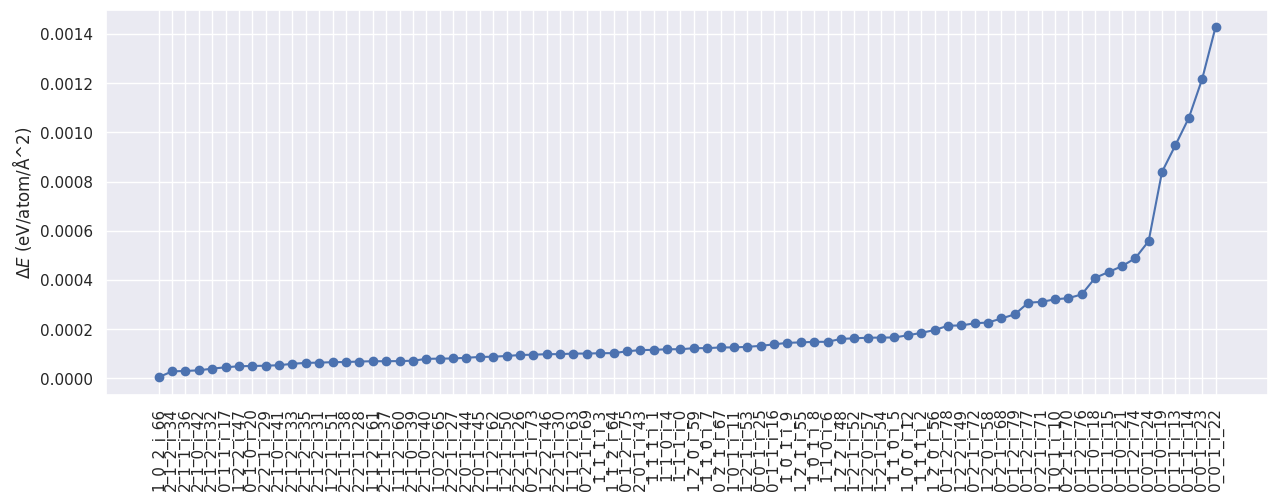

In [9]:
slp.plot_ranking(surface_energies_of_formation,
                filename=f'{slab_folder}/ranking.eps')